### 6. Mediciones con ruido y mínimos cuadrados

#### a)

In [1]:
import numpy as np

from funciones import (N, X_fantoma, xfantoma, matriz_proyeccion, )

# Direcciones
D2 = [(1, 0), (0, 1)]
D4 = D2 + [(1, 1), (1, -1)]
D7 = D4 + [(2, 1), (1, 2), (3, 1)]

# matriz A7
A7, rayos7 = matriz_proyeccion(N, D7)

In [2]:
#Primero calculamos las mediciones limpias:
b7 = A7 @ xfantoma

#fijamos una semilla
np.random.seed(0)

#generamos un único vector
z = np.random.randn(len(b7))
escala = np.sqrt(np.mean(b7**2))

#Definimos los niveles de ruido
sigmas = [0, 0.01, 0.03, 0.06, 0.10]

#generamos las mediciones ruidosas
mediciones_ruidosas = {}

for sigma in sigmas:
    eta_sigma = sigma * escala * z
    b_sigma = b7 + eta_sigma
    mediciones_ruidosas[sigma] = b_sigma

Se generó un solo vector de ruido y se usó para todos los valores de σ. Lo único que cambia es qué tan fuerte es ese ruido. La escala se calcula usando el tamaño típico de las mediciones originales, así que cuanto mayor es σ, más ruido tienen las mediciones.


Ahora, para cada b_sigma, buscamos:

$ \hat x_\sigma $

que minimiza:

$
\|A_7 x - b_\sigma\|^2
$

In [3]:
x_sombrero, _, _, _ = np.linalg.lstsq(A7, b_sigma, rcond=None)

Para cada reconstrucción calculamos algunas medidas para comparar qué tan bien funciona:

- **Norma del ruido:** mide qué tan grande es el ruido que agregamos a las mediciones. $\|\eta_\sigma\|$

- **Norma del residuo:** mide qué tan lejos quedan las mediciones reconstruidas de las mediciones con ruido. $\|b_\sigma - A_7 \hat{x}_\sigma\|$

- **Error relativo:** compara la reconstrucción obtenida con el fantoma original. Cuanto más chico sea, mejor es la reconstrucción. $\frac{\|\hat{x}_\sigma - x_{fantoma}\|}{\|x_{fantoma}\|}$

- **Valor mínimo y máximo:** muestran cuáles son los valores más chico y más grande que aparecen en la reconstrucción.

In [4]:
resultados = []
reconstrucciones = {}

for sigma in sigmas:
    
    eta_sigma = sigma * escala * z
    b_sigma = b7 + eta_sigma

    x_sombrero, _, _, _ = np.linalg.lstsq(A7, b_sigma, rcond=None)

    reconstrucciones[sigma] = x_sombrero

    norma_ruido = np.linalg.norm(eta_sigma)
    residuo = b_sigma - A7 @ x_sombrero
    norma_residuo = np.linalg.norm(residuo)

    error_relativo = (np.linalg.norm(x_sombrero - xfantoma)/ np.linalg.norm(xfantoma))

    minimo = np.min(x_sombrero)
    maximo = np.max(x_sombrero)

    resultados.append([
        sigma,
        norma_ruido,
        norma_residuo,
        error_relativo,
        minimo,
        maximo
    ])

In [5]:
import pandas as pd

tabla = pd.DataFrame(
    resultados,
    columns=[
        "sigma",
        "norma_ruido",
        "norma_residuo",
        "error_relativo",
        "min",
        "max"
    ]
)

tabla

,sigma,norma_ruido,norma_residuo,error_relativo,min,max
0,0.00,0.000000,1.131330e-14,1.730300e-15,-1.110223e-15,0.800000
1,0.01,0.126122,8.986139e-02,1.758685e-02,-9.847911e-03,0.809298
2,0.03,0.378366,2.695842e-01,5.276055e-02,-2.954373e-02,0.827895
3,0.06,0.756732,5.391683e-01,1.055211e-01,-5.908747e-02,0.855790
4,0.10,1.261220,8.986139e-01,1.758685e-01,-9.847911e-02,0.892983


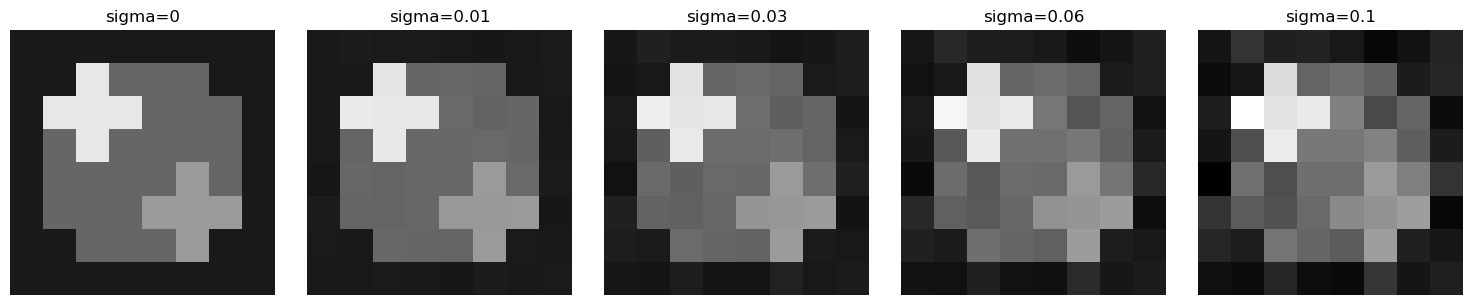

In [6]:
import matplotlib.pyplot as plt

vmin = min(np.min(x) for x in reconstrucciones.values())
vmax = max(np.max(x) for x in reconstrucciones.values())

plt.figure(figsize=(15, 3))

for k, sigma in enumerate(sigmas):
    
    X_rec = reconstrucciones[sigma].reshape(8, 8)

    plt.subplot(1, 5, k+1)
    plt.imshow(X_rec, cmap="gray", vmin=vmin, vmax=vmax)
    plt.title(f"sigma={sigma}")
    plt.axis("off")

plt.tight_layout()
plt.show()

A medida que aumenta `sigma`, también aumenta el error de reconstrucción. Esto se ve tanto en la tabla como en las imágenes. Con poco ruido la reconstrucción se parece mucho al fantoma original, mientras que con niveles mayores aparecen más diferencias entre los píxeles.

El residuo deja de ser nulo cuando se agrega ruido porque las mediciones perturbadas ya no pueden ser reproducidas exactamente por una imagen mediante `A7 @ x`. Por eso, mínimos cuadrados busca la solución que se acerque lo máximo posible a esas mediciones, pero en general no puede hacer que la diferencia sea exactamente cero.

También pueden aparecer valores negativos en la reconstrucción porque `np.linalg.lstsq` busca la mejor solución matemática sin imponer que los valores de los píxeles sean no negativos. Por eso, aunque físicamente los coeficientes de atenuación deberían ser mayores o iguales a cero, la solución obtenida puede contener algunos valores negativos.